In [1]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import PIL.Image
from transformers import AutoImageProcessor
from transformers.models.detr import DetrForSegmentation
import torch
import PIL
import io
import base64
from transformers import AutoModel, AutoTokenizer

import os
import tempfile

import ollama

In [3]:
img_proc = AutoImageProcessor.from_pretrained(
    "cmarkea/detr-layout-detection"
)
model = DetrForSegmentation.from_pretrained(
    "cmarkea/detr-layout-detection"
)

/home/proven/vlm_data_extraction/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
# Görseli aç
img = PIL.Image.open("/home/proven/vlm_data_extraction/data/image/fatura_rıdvan_abi.jpeg")

# Görselin boyutlarını ters sırayla al (height, width)
target_size = [img.size[::-1]]  # (H, W)

# Modeli çalıştır
with torch.inference_mode():
    inputs = img_proc(img, return_tensors='pt')
    outputs = model(**inputs)

In [5]:
# Bounding box'ları al
threshold = 0.80
results = img_proc.post_process_object_detection(
    outputs, threshold=threshold, target_sizes=target_size)[0]

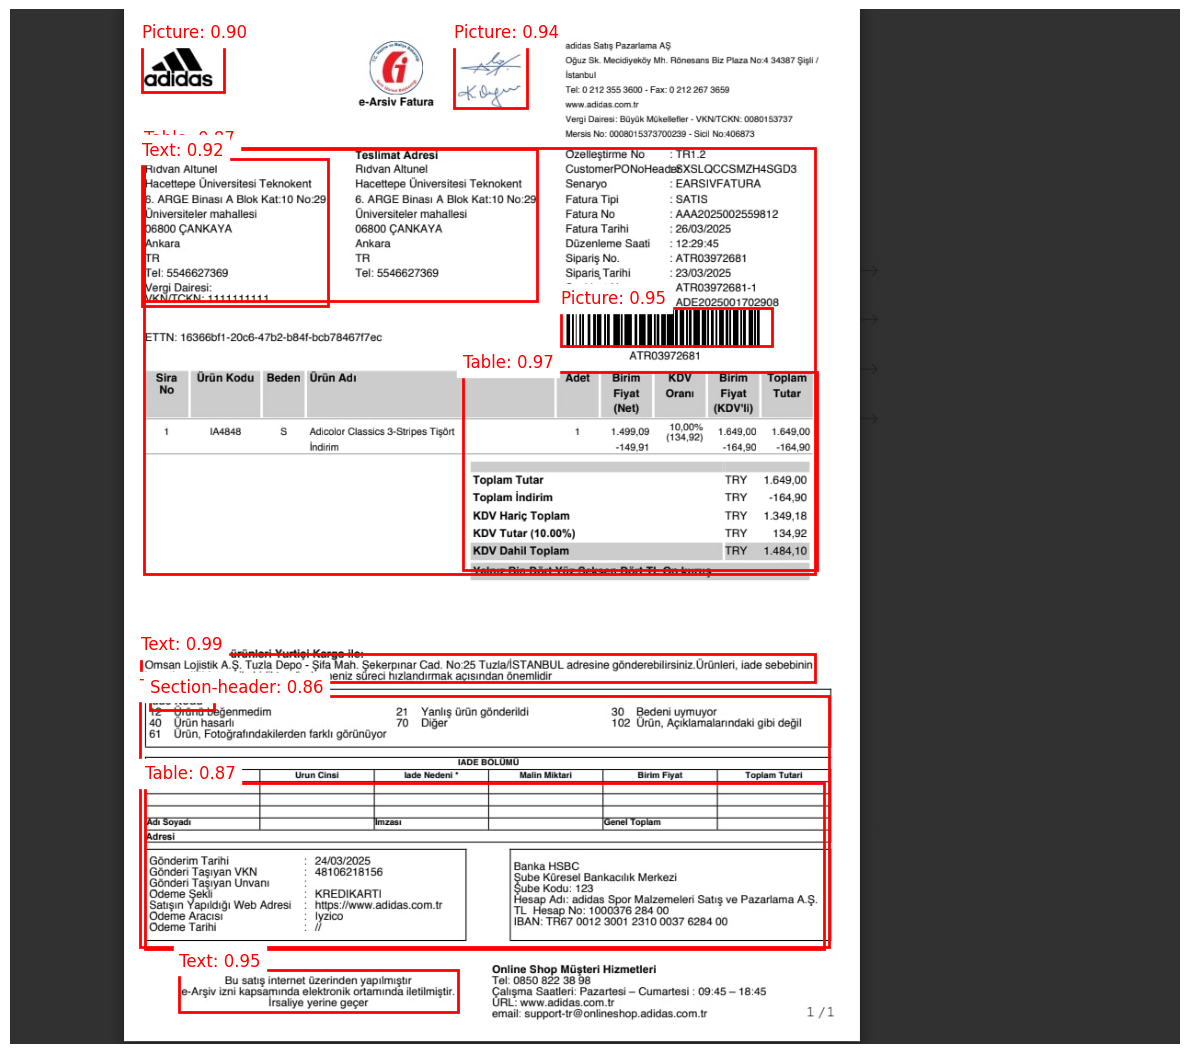

In [6]:
# Görsel üzerine bbox'ları çiz
fig, ax = plt.subplots(1, figsize=(12, 12))
ax.imshow(img)

for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
    
    xmin, ymin, xmax, ymax = box.tolist()
    width = xmax - xmin
    height = ymax - ymin

    # Kutu
    rect = patches.Rectangle((xmin, ymin), width, height,
                             linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)

    # Etiket ve skor
    label_text = f"{model.config.id2label[label.item()]}: {score:.2f}"
    ax.text(xmin, ymin - 5, label_text, color='red',
            fontsize=12, backgroundcolor='white')

plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:


def crop_image(image: PIL.Image, bboxes: list) -> list:
    cropped_images = []
    for bbox in bboxes:
        xmin, ymin, xmax, ymax = [int(point) for point in bbox]
        cropped_image = image.crop((xmin, ymin, xmax, ymax))
        cropped_images.append(cropped_image)
    return cropped_images


def extract_text_OCR(cropped_images):
    import os
    import tempfile
    
    total_string = ""
    tokenizer = AutoTokenizer.from_pretrained('ucaslcl/GOT-OCR2_0', trust_remote_code=True)
    model = AutoModel.from_pretrained('ucaslcl/GOT-OCR2_0', trust_remote_code=True, 
                                     low_cpu_mem_usage=True, device_map='cuda', 
                                     use_safetensors=True, pad_token_id=tokenizer.eos_token_id)
    model = model.eval().cuda()
    
    # Create a temporary directory to store images
    with tempfile.TemporaryDirectory() as temp_dir:
        for i, piece in enumerate(cropped_images):
            # Save each image temporarily
            temp_path = os.path.join(temp_dir, f"temp_image_{i}.png")
            piece.save(temp_path)
            
            # Now pass the file path to the model
            res = model.chat(tokenizer, temp_path, ocr_type='ocr')
            
            # Append the result to the total string
            total_string += f"Text Cluster_{i}: {res}" + "\n\n"
    
    return total_string

# # Use the function
# boundry_boxes = results["boxes"].tolist()
# cropped_image_list = crop_image(img, boundry_boxes)
# text = extract_text_OCR(cropped_image_list)
# print(text)


In [8]:
def get_information(raw_text):
    query = f"""Analyze the following text extracted from an invoice and format it into a JSON structure. Return ONLY the JSON output without any additional text or explanation.
                If any field is not explicitly labeled, infer its value based on context or common synonyms.
                Fields to extract:
                1. Total Amount (with tax, what the customer must pay) — may appear as "Vergiler Dahil Toplam Tutar", "Ödenecek Tutar", or similar. 
                2. Invoice Log Number — labeled as "E-Arşiv No", "E-ARŞİV NO", or similar. It must be a code
                3. Seller's Registration Number — labeled as , "VKN", "TCKN", or similar. It must be a code
                Return result in this exact JSON format:
                {{
                "toplam tutar": "",
                "fatura no": "",
                "satici no": ""
                }}
                
                text: {raw_text}
                """
    response = ollama.chat(
        model='gemma3:4b',
        messages=[
            {'role': 'system', 'content': 'you are an invoice extraction expert.'},
            {
                'role': 'user',
                'content': query,
            }
        ]
    )
    return response['message']['content']

In [9]:
boundry_boxes = results["boxes"].tolist()
cropped_image_list = crop_image(img, boundry_boxes)
text = extract_text_OCR(cropped_image_list)
info = get_information(text)

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end gene

In [10]:
print(info)

```json
{
  "toplam tutar": "1.649,00",
  "fatura no": "AAA2025002559812",
  "satici no": "11111111111"
}
```


In [11]:
print(text)

Text Cluster_0: *  K

Text Cluster_1: Fatura Adres i Te slim at Adres i Rid van Altu nel Rid van Altu nel Hace tte pe Universit es i Tek no kent Hace tte pe Universit es i Tek no kent 6. ARGE Bin as iA Blok Kat: 10 No: 29 6. ARGE Bin as iA Blok Kat: 10 No:  06800 CAN KAYA 06800 CAN KAYA Ankara Ankara TR TR Tel: 5546627369 Tel: 5546627369 Ver giD aires i:

Text Cluster_2: adidas

Text Cluster_3: FaturaAdresi TeslimatAdresi OzellegistirmeNo :TR1.2 RidvanAltunel RidvanAltunel CustomerPONoHeadeBXSLQCCSMZH4SGD3 HacettepeUniversitesiTeknokent HacettepeUniversitesiTeknokent Senaryo :EARISVATURA 6.ARGENi3ABl6kAT:10No:29 6.ARGENi3ABl6kAT:10No:29 FaturaTipi :SATIS Universitelermahallesi Universitelermahallesi FaturaNo :AAA2025002559812 06800CANKAYA 06800CANKAYA FaturaTarihi :26/03/2025 Ankara Ankara DizenlemeSaati :12:29:45 TR TR SiparisNo :ATR03972681 Tel:5546627369 Tel:5546627369 SiparisTarihi :23/03/2025 VergiDairesi: SevkiyatNo :ATR03972681-1 VKN/TCKN:1111111111 IrsaliyeNo :ADE2025001702908 

In [12]:
# image = PIL.Image.open("/home/proven/vlm_data_extraction/data/image/fatura_rıdvan_abi.jpeg")
path = "/home/proven/vlm_data_extraction/data/image/fatura_rıdvan_abi.jpeg"

tokenizer = AutoTokenizer.from_pretrained('ucaslcl/GOT-OCR2_0', trust_remote_code=True)
model = AutoModel.from_pretrained('ucaslcl/GOT-OCR2_0', trust_remote_code=True, 
                                 low_cpu_mem_usage=True, device_map='cuda', 
                                 use_safetensors=True, pad_token_id=tokenizer.eos_token_id)
model = model.eval().cuda()

res = model.chat(tokenizer, path, ocr_type='ocr')



The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


In [13]:
print(res)

adidas Saty Panarmina AS
Ogur St. Mocichively Mt. Ronesan Biz Plaza No 43837 Sypi/
Tel. 02 121 85 5800 - Fax: 0 212 267 3659
www.adidas.com.tr
Verg Daires: Byjska Mleeferel – VNVN/TONI: 0800153737
Mersia No: 0000815373700209 – Sci No: 406873
Fatura Adresi
Tevalmat Adresi
Ozellegrime No.       : TRI 2
Rudvan Altenul
Rudvan Altenul
CustomerPONo-Head8/SKLSOCCSMZH4SGD3
Hacettepe Üniversitesi Teknokent
Hacettepe Üniversitesi Teknokent
Senayo
: EARSIVFATURA
6. ARGE Binas & Blok Kat:10 No 229
6. ARGE Binas A Blok Kat:10 No 29
Fatura Tipi
: SATIS
Universiterel mahallesi
Universiterel mahallesi
Fatura No
: AAA20250025598812
06800 ČANKAYA
06800 ČANKAYA
Fatura Tarihi
: 260/32025
Ankara
Ankara
Düzenlemie Saat
: 12:29-45
TR
TR
Siparis No.
: ATRD3972681
Tel: 5546627369
Tel: 5546627369
Siparis Tarihi
: 23/03/2025
Verg Dairesi:
Sewkyyat No
: ATRD3972681-1
VR0/TCKN: 1111111111
Issalie No
: ADE2025001702508
ETN: 16366b1-2006-47b2-b84-bcb784677fec
ATR03972681
Sira
No
Urūn Kodu
Beden
Urūn Adi
Ade
Birim
KD

In [14]:
info = get_information(res)
print(info)

```json
{
  "toplam tutar": "1.649,00",
  "fatura no": "AAA20250025598812",
  "satici no": "1111111111"
}
```


In [2]:
from src.extract_data import ExtractData
from doclayout_yolo import YOLOv10


class ExtractDataFromImageYOLO(ExtractData):
    def __init__(self):
        super().__init__()
        self.model = YOLOv10(
            "models/doclayout_yolo_docstructbench_imgsz1024.pt")
        self.device = "cuda:0"
        self.conf = 0.1
        self.imgsize = 1024

        self.tokenizer = AutoTokenizer.from_pretrained(
            'ucaslcl/GOT-OCR2_0', trust_remote_code=True)
        self.ocr_model = AutoModel.from_pretrained('ucaslcl/GOT-OCR2_0', trust_remote_code=True, low_cpu_mem_usage=True,
                                                   device_map='cuda', use_safetensors=True, pad_token_id=self.tokenizer.eos_token_id)
        self.ocr_model = self.ocr_model.eval().cuda()

    def _get_yolo_attr(self, boxes):
        bboxes = boxes.xyxy.cpu().numpy()
        classes = boxes.cls.cpu().numpy()
        class_names = self.model.names if hasattr(
            self.model, 'names') else None

        bboxes = []
        labels = []
        for box in range(len(bboxes)):
            x1, y1, x2, y2 = bboxes[box]
            class_idx = int(classes[box])
            label = class_names[class_idx] if class_names else f"Class {class_idx}"

            bboxes.append([int(x1), int(y1), int(x2), int(y2)])
            labels.append(label)

        return bboxes, labels

    def _get_bbox_with_yolo(self, image_path):
        results = self.model.predict(
            image_path,
            imgsz=self.device,
            conf=self.conf,
            device=self.imgsize
        )
        boxes = results.boxes
        bboxes, labels = self._get_yolo_attr(boxes)
        return bboxes, labels

    def _crop_yolo_image(self, image_path: str, bboxes, labels) -> list:
        cropped_images = ["figure", "abandon", "figure_caption"]
        image = PIL.Image.open(image_path)
        for bbox, label in zip(bboxes, labels):
            if label not in ["figure", "abandon", "figure_caption"]:
                xmin, ymin, xmax, ymax = bbox
                cropped_image = image.crop((xmin, ymin, xmax, ymax))
                cropped_images.append(cropped_image)

    def extract_text_with_OCR(self, image_path: str):
        total_string = ""
        bboxes, labels = self._get_bbox_with_yolo(image_path)
        cropped_images = self._crop_yolo_image(image_path, bboxes, labels)

        with tempfile.TemporaryDirectory() as temp_dir:
            # Save each image temporarily
            for i, piece in enumerate(cropped_images):
                temp_path = os.path.join(temp_dir, f"temp_image_{i}.png")
                piece.save(temp_path)
                res = self.ocr_model.chat(
                    self.tokenizer, temp_path, ocr_type='ocr')

                total_string += f"Text Cluster_{i}: {res}" + "\n\n"
        return total_string


In [3]:
lelelel = ExtractDataFromImageYOLO()
img= "data/image/fatura_rıdvan_abi.jpeg"

def extract_image(object: ExtractDataFromImageYOLO, image_file):
        text = object.extract_text_with_OCR(image_file)
        information = object.get_information(text)

        return information

inf = extract_image(lelelel, img)


/home/proven/vlm_data_extraction/.venv/lib/python3.12/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Ultralytics YOLOv0.0.3 🚀 Python-3.12.3 torch-2.6.0+cu124 


ValueError: Invalid CUDA 'device=1024' requested. Use 'device=cpu' or pass valid CUDA device(s) if available, i.e. 'device=0' or 'device=0,1,2,3' for Multi-GPU.

torch.cuda.is_available(): True
torch.cuda.device_count(): 0
os.environ['CUDA_VISIBLE_DEVICES']: None
See https://pytorch.org/get-started/locally/ for up-to-date torch install instructions if no CUDA devices are seen by torch.
